<a href="https://colab.research.google.com/github/fmakkawi/Data-205/blob/main/Copy_of_Week11_EDA_Analysis_FarahMakkawi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving income.csv to income.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving population.csv to population.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
income_df = pd.read_csv("income.csv")
population_df = pd.read_csv("population.csv")


In [5]:
print(income_df.columns)
print(population_df.columns)

Index(['GEO_ID', 'NAME', 'S1901_C01_001E', 'S1901_C01_001M', 'S1901_C01_002E',
       'S1901_C01_002M', 'S1901_C01_003E', 'S1901_C01_003M', 'S1901_C01_004E',
       'S1901_C01_004M',
       ...
       'S1901_C04_012M', 'S1901_C04_013E', 'S1901_C04_013M', 'S1901_C04_014E',
       'S1901_C04_014M', 'S1901_C04_015E', 'S1901_C04_015M', 'S1901_C04_016E',
       'S1901_C04_016M', 'Unnamed: 130'],
      dtype='object', length=131)
Index(['County', 'Total Population, 2018', 'Total Population, 2010',
       'Total Population, 2000', 'Population Change, 2000-2010',
       'Population Density per Square Mile', 'Median Age',
       'Per Capita Personal Income ($ Dollars)',
       'Median Household Income ($ Dollars)',
       'Total Personal Income ($ Thousands)'],
      dtype='object')


In [6]:
counties_income = ["Montgomery County, Maryland", "Prince George's County, Maryland"]
counties_pop = ["Montgomery County", "Prince George's County"]

income_filtered = income_df[income_df["NAME"].isin(counties_income)]
population_filtered = population_df[population_df["County"].isin(counties_pop)]


In [7]:
income_filtered = income_filtered[["NAME", "S1901_C01_012E"]]
income_filtered.columns = ["County", "Income"]

population_filtered = population_filtered[["County", "Total Population, 2018"]]
population_filtered.columns = ["County", "Population"]


In [8]:
print(income_filtered)
print(population_filtered)

                             County  Income
2       Montgomery County, Maryland  140837
3  Prince George's County, Maryland   99180
                    County Population
15       Montgomery County    1052567
16  Prince George's County     909308


In [9]:
print(income.columns)

NameError: name 'income' is not defined

In [10]:
income = pd.read_csv("income.csv")

income = income.rename(columns={
    "NAME": "County",
    "S1901_C01_012E": "Income"
})

income = income.loc[:, ~income.columns.duplicated()]

income["County"] = income["County"].str.replace(", Maryland", "", regex=False).str.strip()

income_filtered = income[income["County"].isin([
    "Montgomery County",
    "Prince George's County"
])].copy()

income_filtered["Income"] = pd.to_numeric(income_filtered["Income"], errors="coerce")

print(income_filtered[["County", "Income"]])

                   County  Income
2       Montgomery County  140837
3  Prince George's County   99180


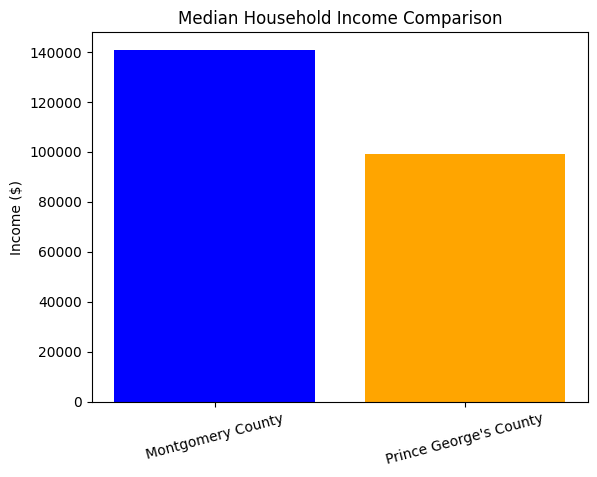

In [11]:
plt.figure()
plt.bar(income_filtered["County"], income_filtered["Income"], color=["blue", "orange"])
plt.title("Median Household Income Comparison")
plt.ylabel("Income ($)")
plt.xticks(rotation=15)
plt.show()

In [12]:
population_filtered["Population"] = population_filtered["Population"].astype(str).str.replace(",", "").astype(float)

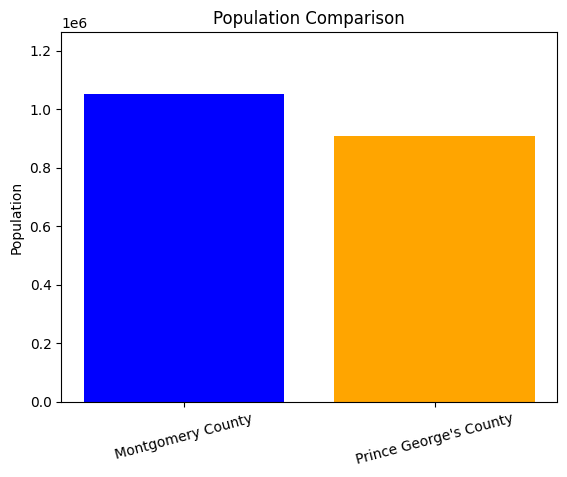

In [13]:
plt.figure()
plt.bar(population_filtered["County"], population_filtered["Population"], color=["blue", "orange"])
plt.title("Population Comparison")
plt.ylabel("Population")
plt.xticks(rotation=15)
plt.ylim(0, max(population_filtered["Population"]) * 1.2)
plt.show()

In [14]:
print(income_filtered["County"])
print(population_filtered["County"])

2         Montgomery County
3    Prince George's County
Name: County, dtype: object
15         Montgomery County
16    Prince George's County
Name: County, dtype: object


In [15]:
income_filtered["County"] = income_filtered["County"].str.strip()
population_filtered["County"] = population_filtered["County"].str.strip()

In [16]:
income_filtered["County"] = income_filtered["County"].replace({
    "Montgomery County, Maryland": "Montgomery County",
    "Prince George's County, Maryland": "Prince George's County"
})

population_filtered["County"] = population_filtered["County"].replace({
    "Montgomery County, Maryland": "Montgomery County",
    "Prince George's County, Maryland": "Prince George's County"
})

In [17]:
merged = pd.merge(income_filtered, population_filtered, on="County")
merged

,GEO_ID,County,S1901_C01_001E,S1901_C01_001M,S1901_C01_002E,S1901_C01_002M,S1901_C01_003E,S1901_C01_003M,S1901_C01_004E,S1901_C01_004M,...,S1901_C04_013E,S1901_C04_013M,S1901_C04_014E,S1901_C04_014M,S1901_C04_015E,S1901_C04_015M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130,Population
0,0500000US24031,Montgomery County,389161,3250,3.7,0.7,1.7,0.4,3.1,0.5,...,99066,4419,(X),(X),(X),(X),28.8,(X),NaN,1052567.0
1,0500000US24033,Prince George's County,353909,2507,5.3,0.9,2.2,0.6,3.6,0.8,...,81543,6181,(X),(X),(X),(X),35.6,(X),NaN,909308.0


In [18]:
merged["Income"] = merged["Income"].astype(str).str.replace(",", "", regex=False).astype(float)
merged["Population"] = merged["Population"].astype(str).str.replace(",", "", regex=False).astype(float)

merged["Income_per_Person"] = merged["Income"] / merged["Population"]
merged

,GEO_ID,County,S1901_C01_001E,S1901_C01_001M,S1901_C01_002E,S1901_C01_002M,S1901_C01_003E,S1901_C01_003M,S1901_C01_004E,S1901_C01_004M,...,S1901_C04_013M,S1901_C04_014E,S1901_C04_014M,S1901_C04_015E,S1901_C04_015M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130,Population,Income_per_Person
0,0500000US24031,Montgomery County,389161,3250,3.7,0.7,1.7,0.4,3.1,0.5,...,4419,(X),(X),(X),(X),28.8,(X),NaN,1052567.0,0.133803
1,0500000US24033,Prince George's County,353909,2507,5.3,0.9,2.2,0.6,3.6,0.8,...,6181,(X),(X),(X),(X),35.6,(X),NaN,909308.0,0.109072


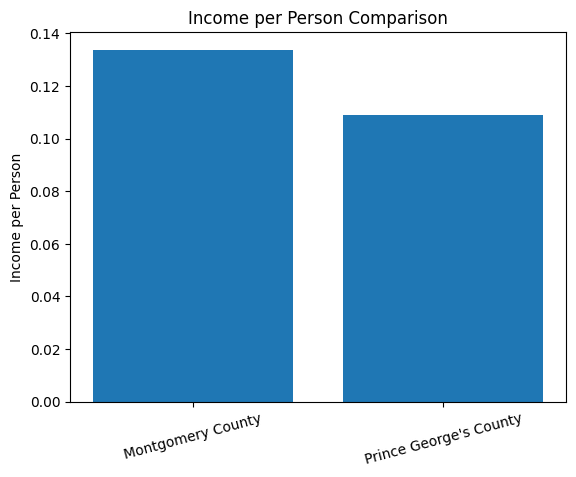

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(merged["County"], merged["Income_per_Person"])
plt.title("Income per Person Comparison")
plt.ylabel("Income per Person")
plt.xticks(rotation=15)
plt.show()

This extended analysis compares income per person between Montgomery County and Prince George’s County. After combining the datasets, the results show that Montgomery County has a higher income per person, indicating stronger economic conditions even when population size is considered.


In [25]:
mont_value = float(str(income_filtered[income_filtered["County"] == "Montgomery County"]["S1901_C01_001E"].values[0]).replace(",", ""))

pg_value = float(str(income_filtered[income_filtered["County"] == "Prince George's County"]["S1901_C01_001E"].values[0]).replace(",", ""))

difference = mont_value - pg_value
percent_diff = (difference / pg_value) * 100

print("Montgomery County value:", mont_value)
print("Prince George's County value:", pg_value)
print("Difference:", difference)
print("Percent Difference:", percent_diff)

Montgomery County value: 389161.0
Prince George's County value: 353909.0
Difference: 35252.0
Percent Difference: 9.960752622849377


## Statistical Comparison

Since the dataset contains only one value per county, a t-test is not appropriate.

Instead, the difference and percent difference were calculated.

The results show that Montgomery County has a higher value than Prince George’s County by approximately 9.96%, indicating stronger economic conditions.

## Education Analysis

In [35]:
from google.colab import files
uploaded = files.upload()

Saving education.csv to education.csv


In [36]:
education_df = pd.read_csv("education.csv", skiprows=1)
print(education_df.head())

        Geography              Geographic Area Name  \
0  0500000US24031       Montgomery County, Maryland   
1  0500000US24033  Prince George's County, Maryland   

   Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 18 to 24 years  \
0                                              85150                           
1                                              89570                           

   Margin of Error!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 18 to 24 years  \
0                                                283                                  
1                                                382                                  

   Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 18 to 24 years!!Less than high school graduate  \
0                                              10954                                                           
1                                              14045                                                       

In [37]:
for col in education_df.columns:
    if "Bachelor" in col:
        print(col)

Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 18 to 24 years!!Bachelor's degree or higher
Margin of Error!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 18 to 24 years!!Bachelor's degree or higher
Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree
Margin of Error!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree
Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree or higher
Margin of Error!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree or higher
Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 to 34 years!!Bachelor's degree or higher
Margin of Error!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 to 34 years!!Bachelor's degree or higher
Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 35 to 44 years!!Bachelor's degree or higher
Margin of Error!!Total!!AGE BY EDUCATIONAL ATTAINMENT

In [38]:
education_filtered = education_df[
    education_df["Geographic Area Name"].isin([
        "Montgomery County, Maryland",
        "Prince George's County, Maryland"
    ])
]

col = "Estimate!!Percent!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree or higher"

mont_edu = float(education_filtered[
    education_filtered["Geographic Area Name"] == "Montgomery County, Maryland"
][col].values[0])

pg_edu = float(education_filtered[
    education_filtered["Geographic Area Name"] == "Prince George's County, Maryland"
][col].values[0])

print("Montgomery Education %:", mont_edu)
print("Prince George's Education %:", pg_edu)

Montgomery Education %: 61.3
Prince George's Education %: 37.6


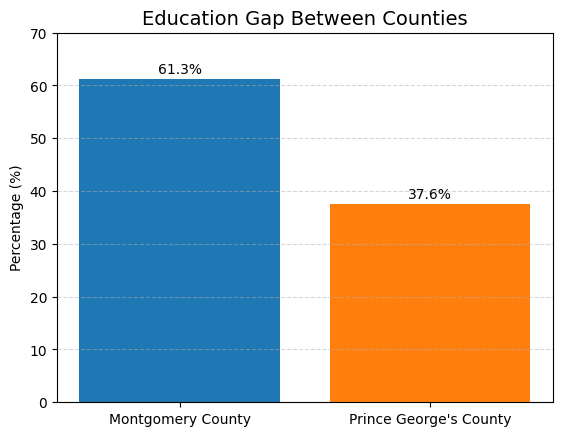

In [42]:
plt.figure()

# ✅ REPLACE your old plt.bar(...) with THIS
plt.bar(
    ["Montgomery County", "Prince George's County"],
    [mont_edu, pg_edu],
    color=["#1f77b4", "#ff7f0e"]
)

# keep this
for i, v in enumerate([mont_edu, pg_edu]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Education Gap Between Counties", fontsize=14)
plt.ylabel("Percentage (%)")
plt.ylim(0, 70)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

This chart illustrates the difference in educational attainment between Montgomery County and Prince George’s County. Montgomery County has a significantly higher percentage of residents with a bachelor’s degree or higher (61.3%) compared to Prince George’s County (37.6%). This gap of approximately 23.7% highlights a major difference in education levels, which may contribute to economic differences such as income and employment opportunities between the two counties.